# Kenya Food Security Data Analysis

This notebook analyzes Kenya food security data from two sources:

- FAOSTAT food security datasets from HDX for national-level trends.
- World Bank Joint Food Security Monitor (JMR) data for county and sub-county food security risk mapping.

The workflow uses Pandas for cleaning and `pd.merge`, Matplotlib/Seaborn for statistics and charts, and GeoPandas for map-ready county visualizations.


## Project Questions

1. What national food security and healthy diet affordability trends are visible in the FAOSTAT data?
2. Which counties show higher food security risk in the World Bank JMR data?
3. How can the JMR admin-2 data be aggregated to counties and joined to county boundaries?
4. What visualizations best communicate the national trend and county risk patterns?


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

DATA_DIR = Path("../data")
JMR_DIR = DATA_DIR / "world_bank_jmr"
SHAPEFILE_DIR = DATA_DIR / "shapefiles"
import plotly.graph_objects as go


## 1. Load FAOSTAT / HDX National Data


In [2]:
food_security = pd.read_csv(DATA_DIR / "ken_faostat_food_security_indicators.csv")
food_balances = pd.read_csv(DATA_DIR / "ken_faostat_food_balances.csv")
healthy_diet = pd.read_csv(DATA_DIR / "ken_faostat_cost_affordability_healthy_diet.csv")

datasets = {
    "food_security": food_security,
    "food_balances": food_balances,
    "healthy_diet": healthy_diet,
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
    display(df.head(3))

food_security: 1,127 rows x 16 columns


,Iso3,StartDate,EndDate,Area Code,Area Code (M49),Area,Item Code,Item,Element Code,Element,Year Code,Year,Unit,Value,Flag,Note
0,KEN,2000-01-01,2002-12-31,114,'404,Kenya,21010,Average dietary energy supply adequacy (percen...,6121,Value,20002002,2002,%,93.0,E,NaN
1,KEN,2001-01-01,2003-12-31,114,'404,Kenya,21010,Average dietary energy supply adequacy (percen...,6121,Value,20012003,2003,%,92.0,E,NaN
2,KEN,2002-01-01,2004-12-31,114,'404,Kenya,21010,Average dietary energy supply adequacy (percen...,6121,Value,20022004,2004,%,92.0,E,NaN


food_balances: 25,330 rows x 17 columns


,Iso3,StartDate,EndDate,Area Code,Area Code (M49),Area,Item Code,Item Code (FBS),Item,Element Code,Element,Year Code,Year,Unit,Value,Flag,Note
0,KEN,2010-01-01,2010-12-31,114,'404,Kenya,2501,'S2501,Population,511,Total Population - Both sexes,2010,2010,1000 No,41598.57,X,NaN
1,KEN,2011-01-01,2011-12-31,114,'404,Kenya,2501,'S2501,Population,511,Total Population - Both sexes,2011,2011,1000 No,42758.46,X,NaN
2,KEN,2012-01-01,2012-12-31,114,'404,Kenya,2501,'S2501,Population,511,Total Population - Both sexes,2012,2012,1000 No,43888.30,X,NaN


healthy_diet: 48 rows x 17 columns


,Iso3,StartDate,EndDate,Area Code,Area Code (M49),Area,Item Code,Item,Element Code,Element,Year Code,Year,Release Code,Release,Unit,Value,Flag
0,KEN,2017-01-01,2017-12-31,114,'404,Kenya,70040,Cost of a healthy diet (CoHD),6226,Value,2017,2017,7S2026,July 2026 (SOFI report),Int$ (PPP) per person per day,2.56,E
1,KEN,2018-01-01,2018-12-31,114,'404,Kenya,70040,Cost of a healthy diet (CoHD),6226,Value,2018,2018,7S2026,July 2026 (SOFI report),Int$ (PPP) per person per day,2.62,E
2,KEN,2019-01-01,2019-12-31,114,'404,Kenya,70040,Cost of a healthy diet (CoHD),6226,Value,2019,2019,7S2026,July 2026 (SOFI report),Int$ (PPP) per person per day,2.83,E


In [3]:
coverage = []
for name, df in datasets.items():
    coverage.append({
        "dataset": name,
        "rows": len(df),
        "columns": df.shape[1],
        "min_year": int(df["Year"].min()),
        "max_year": int(df["Year"].max()),
        "unique_items": df["Item"].nunique(),
        "unique_units": df["Unit"].nunique(),
    })

display(pd.DataFrame(coverage))

,dataset,rows,columns,min_year,max_year,unique_items,unique_units
0,food_security,1127,16,2000,2025,47,7
1,food_balances,25330,17,2010,2023,119,7
2,healthy_diet,48,17,2017,2025,9,4


## 2. Clean and Reshape FAOSTAT Indicators

The FAOSTAT files are long tables, so selected indicators are pivoted into a year-level table for Kenya.


In [4]:
def clean_base(df):
    cleaned = df.copy()
    cleaned.columns = cleaned.columns.str.strip()
    cleaned["Year"] = pd.to_numeric(cleaned["Year"], errors="coerce").astype("Int64")
    cleaned["Value"] = pd.to_numeric(cleaned["Value"], errors="coerce")
    cleaned["Area"] = cleaned["Area"].astype(str).str.strip()
    cleaned["Iso3"] = cleaned["Iso3"].astype(str).str.strip()
    return cleaned

food_security_clean = clean_base(food_security)
food_balances_clean = clean_base(food_balances)
healthy_diet_clean = clean_base(healthy_diet)

KEYS = ["Iso3", "Area", "Year"]

In [5]:
def pivot_indicators(df, item_map, value_col="Value"):
    selected = df[df["Item"].isin(item_map.keys())].copy()
    selected["indicator"] = selected["Item"].map(item_map)
    wide = (
        selected
        .pivot_table(index=KEYS, columns="indicator", values=value_col, aggfunc="mean")
        .reset_index()
    )
    wide.columns.name = None
    return wide

food_security_items = {
    "Average dietary energy supply adequacy (percent) (3-year average)": "dietary_energy_adequacy_pct",
    "Prevalence of undernourishment (percent) (3-year average)": "undernourishment_pct",
    "Number of people undernourished (million) (3-year average)": "undernourished_people_million",
    "Prevalence of severe food insecurity in the total population (percent) (3-year average)": "severe_food_insecurity_pct",
    "Prevalence of moderate or severe food insecurity in the total population (percent) (3-year average)": "moderate_or_severe_food_insecurity_pct",
    "Percentage of children under 5 years of age who are stunted (modelled estimates) (percent)": "under5_stunting_pct",
    "Percentage of children under 5 years affected by wasting (percent)": "under5_wasting_pct",
    "Gross domestic product per capita, PPP, (constant 2021 international $)": "gdp_per_capita_ppp",
}

healthy_diet_items = {
    "Cost of a healthy diet (CoHD)": "healthy_diet_cost_ppp_per_day",
    "Prevalence of unaffordability (PUA)": "healthy_diet_unaffordable_pct",
    "Number of people unable to afford a healthy diet (NUA)": "people_unable_afford_healthy_diet_million",
}

fsi_wide = pivot_indicators(food_security_clean, food_security_items)
cohd_wide = pivot_indicators(healthy_diet_clean, healthy_diet_items)

display(fsi_wide.head())
display(cohd_wide.head())

,Iso3,Area,Year,dietary_energy_adequacy_pct,gdp_per_capita_ppp,moderate_or_severe_food_insecurity_pct,severe_food_insecurity_pct,under5_stunting_pct,under5_wasting_pct,undernourished_people_million,undernourishment_pct
0,KEN,Kenya,2000,NaN,3757.0,NaN,NaN,38.6,7.4,NaN,NaN
1,KEN,Kenya,2001,NaN,3778.0,NaN,NaN,38.5,NaN,NaN,NaN
2,KEN,Kenya,2002,93.0,3681.0,NaN,NaN,38.5,NaN,10.1,31.8
3,KEN,Kenya,2003,92.0,3674.0,NaN,NaN,38.2,6.2,10.9,33.3
4,KEN,Kenya,2004,92.0,3744.0,NaN,NaN,37.8,NaN,11.6,34.5


,Iso3,Area,Year,healthy_diet_cost_ppp_per_day,healthy_diet_unaffordable_pct,people_unable_afford_healthy_diet_million
0,KEN,Kenya,2017,57.180,69.8,34.3
1,KEN,Kenya,2018,57.990,69.8,35.1
2,KEN,Kenya,2019,62.695,72.1,36.9
3,KEN,Kenya,2020,68.420,76.3,39.8
4,KEN,Kenya,2021,74.265,78.0,41.5


## 3. Prepare FAOSTAT Food Balance Indicators


In [6]:
population = (
    food_balances_clean[
        (food_balances_clean["Item"] == "Population")
        & (food_balances_clean["Element"] == "Total Population - Both sexes")
    ][KEYS + ["Value"]]
    .rename(columns={"Value": "population_thousand"})
)

food_supply = (
    food_balances_clean[
        (food_balances_clean["Item"] == "Grand Total")
        & (food_balances_clean["Element"] == "Food supply (kcal/capita/day)")
    ][KEYS + ["Value"]]
    .rename(columns={"Value": "food_supply_kcal_capita_day"})
)

protein_supply = (
    food_balances_clean[
        (food_balances_clean["Item"] == "Grand Total")
        & (food_balances_clean["Element"] == "Protein supply quantity (g/capita/day)")
    ][KEYS + ["Value"]]
    .rename(columns={"Value": "protein_supply_g_capita_day"})
)

fat_supply = (
    food_balances_clean[
        (food_balances_clean["Item"] == "Grand Total")
        & (food_balances_clean["Element"] == "Fat supply quantity (g/capita/day)")
    ][KEYS + ["Value"]]
    .rename(columns={"Value": "fat_supply_g_capita_day"})
)

food_balance_wide = population.merge(food_supply, on=KEYS, how="outer")
food_balance_wide = food_balance_wide.merge(protein_supply, on=KEYS, how="outer")
food_balance_wide = food_balance_wide.merge(fat_supply, on=KEYS, how="outer")

display(food_balance_wide.head())

,Iso3,Area,Year,population_thousand,food_supply_kcal_capita_day,protein_supply_g_capita_day,fat_supply_g_capita_day
0,KEN,Kenya,2010,41598.57,2178.21,57.79,54.08
1,KEN,Kenya,2011,42758.46,2185.37,60.58,44.99
2,KEN,Kenya,2012,43888.30,2208.06,60.39,44.23
3,KEN,Kenya,2013,44986.79,2233.44,59.13,54.12
4,KEN,Kenya,2014,46051.44,2230.33,60.45,45.25


## 4. Merge FAOSTAT National Analysis Table

The FAOSTAT tables share `Iso3`, `Area`, and `Year`, so they can be joined using `pd.merge`.


In [7]:
analysis_df = fsi_wide.merge(food_balance_wide, on=KEYS, how="outer")
analysis_df = analysis_df.merge(cohd_wide, on=KEYS, how="outer")
analysis_df = analysis_df.sort_values("Year").reset_index(drop=True)

print(analysis_df.shape)
display(analysis_df.head())
display(analysis_df.tail())

(26, 18)


,Iso3,Area,Year,dietary_energy_adequacy_pct,gdp_per_capita_ppp,moderate_or_severe_food_insecurity_pct,severe_food_insecurity_pct,under5_stunting_pct,under5_wasting_pct,undernourished_people_million,undernourishment_pct,population_thousand,food_supply_kcal_capita_day,protein_supply_g_capita_day,fat_supply_g_capita_day,healthy_diet_cost_ppp_per_day,healthy_diet_unaffordable_pct,people_unable_afford_healthy_diet_million
0,KEN,Kenya,2000,NaN,3757.0,NaN,NaN,38.6,7.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,KEN,Kenya,2001,NaN,3778.0,NaN,NaN,38.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,KEN,Kenya,2002,93.0,3681.0,NaN,NaN,38.5,NaN,10.1,31.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,KEN,Kenya,2003,92.0,3674.0,NaN,NaN,38.2,6.2,10.9,33.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,KEN,Kenya,2004,92.0,3744.0,NaN,NaN,37.8,NaN,11.6,34.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Iso3,Area,Year,dietary_energy_adequacy_pct,gdp_per_capita_ppp,moderate_or_severe_food_insecurity_pct,severe_food_insecurity_pct,under5_stunting_pct,under5_wasting_pct,undernourished_people_million,undernourishment_pct,population_thousand,food_supply_kcal_capita_day,protein_supply_g_capita_day,fat_supply_g_capita_day,healthy_diet_cost_ppp_per_day,healthy_diet_unaffordable_pct,people_unable_afford_healthy_diet_million
21,KEN,Kenya,2021,97.0,5339.0,69.500000,26.066667,19.2,NaN,15.0,28.8,53219.17,2162.74,55.72,52.38,74.265,78.0,41.5
22,KEN,Kenya,2022,95.0,5492.0,72.266667,28.000000,18.7,4.5,17.8,33.4,54252.46,2137.61,56.54,51.07,83.655,77.8,42.2
23,KEN,Kenya,2023,93.0,5692.0,72.833333,28.033333,18.2,NaN,19.6,36.2,55339.00,2146.01,55.77,48.60,91.730,76.9,42.6
24,KEN,Kenya,2024,93.0,5845.0,73.900000,28.066667,17.9,NaN,20.1,36.4,NaN,NaN,NaN,NaN,96.690,76.4,43.1
25,KEN,Kenya,2025,94.0,NaN,71.733333,26.466667,NaN,NaN,19.7,34.9,NaN,NaN,NaN,NaN,103.525,76.3,43.9


In [8]:
latest_values = []
for col in [c for c in analysis_df.columns if c not in KEYS]:
    latest = analysis_df.dropna(subset=[col]).sort_values("Year").tail(1)
    if not latest.empty:
        latest_values.append({
            "indicator": col,
            "latest_year": int(latest["Year"].iloc[0]),
            "latest_value": latest[col].iloc[0],
        })

latest_df = pd.DataFrame(latest_values).sort_values("indicator")
display(latest_df)

,indicator,latest_year,latest_value
0,dietary_energy_adequacy_pct,2025,94.000000
11,fat_supply_g_capita_day,2023,48.600000
9,food_supply_kcal_capita_day,2023,2146.010000
1,gdp_per_capita_ppp,2024,5845.000000
12,healthy_diet_cost_ppp_per_day,2025,103.525000
13,healthy_diet_unaffordable_pct,2025,76.300000
2,moderate_or_severe_food_insecurity_pct,2025,71.733333
14,people_unable_afford_healthy_diet_million,2025,43.900000
8,population_thousand,2023,55339.000000
10,protein_supply_g_capita_day,2023,55.770000


In [9]:
# Shared status thresholds and colors (match dashboard/config.py)
THRESHOLDS = {
    "dietary_energy_adequacy_pct":      (95,  90,  "higher_is_better"),
    "food_supply_kcal_capita_day":      (2100, 1800, "higher_is_better"),
    "protein_supply_g_capita_day":      (50,  40,  "higher_is_better"),
    "fat_supply_g_capita_day":          (40,  30,  "higher_is_better"),
    "undernourishment_pct":             (15,  25,  "lower_is_better"),
    "undernourished_people_million":    (10,  15,  "lower_is_better"),
    "severe_food_insecurity_pct":       (10,  20,  "lower_is_better"),
    "moderate_or_severe_food_insecurity_pct": (40, 60, "lower_is_better"),
    "under5_stunting_pct":              (20,  30,  "lower_is_better"),
    "under5_wasting_pct":               (5,   15,  "lower_is_better"),
    "healthy_diet_cost_ppp_per_day":    (3.5, 5.0, "lower_is_better"),
    "healthy_diet_unaffordable_pct":    (50,  70,  "lower_is_better"),
    "people_unable_afford_healthy_diet_million": (20, 35, "lower_is_better"),
    "gdp_per_capita_ppp":               (3000, 2000, "higher_is_better"),
}

def status_color(value, indicator):
    warn, danger, direction = THRESHOLDS[indicator]
    if direction == "lower_is_better":
        if value >= danger: return "#e74c3c"
        elif value >= warn: return "#f39c12"
        else: return "#2ecc71"
    else:
        if value <= danger: return "#e74c3c"
        elif value <= warn: return "#f39c12"
        else: return "#2ecc71" 

## 5. National Trend Visualizations (Closing the Streamlit App)

The sections below mirror the **Streamlit dashboard** (`app.py`) tab by tab so the
notebook and the app tell the same story with the same charts, in the same order:

- **Tab 1 - Executive Summary:** key indicators over time + GDP vs food insecurity scatter
- **Tab 2 - Availability:** energy adequacy + food supply breakdown (kcal / protein / fat)
- **Tab 3 - Access & Affordability:** undernourishment, food insecurity severity, affordability crisis
- **Tab 4 - Child Nutrition:** stunting & wasting + GDP per capita context

The color system used throughout matches the app:
- Green = Acceptable - Within safe range
- Yellow = Warning - Needs attention
- Red = Critical - Immediate action required

**Key insight:** While dietary energy adequacy has remained relatively stable (~92-97%),
the number of undernourished Kenyans has grown from ~10 million (2002) to ~20 million (2025)
driven by population growth outpacing food system improvements.

### 5.1 Tab 1 - Executive Summary: Key Food Security Indicators Over Time

This is the same line chart shown at the top of the Executive Summary tab in the app.
It combines three very different scales (millions of people, percentages of population,
and percentage of calorie needs met) to tell the "big picture" story in one view.

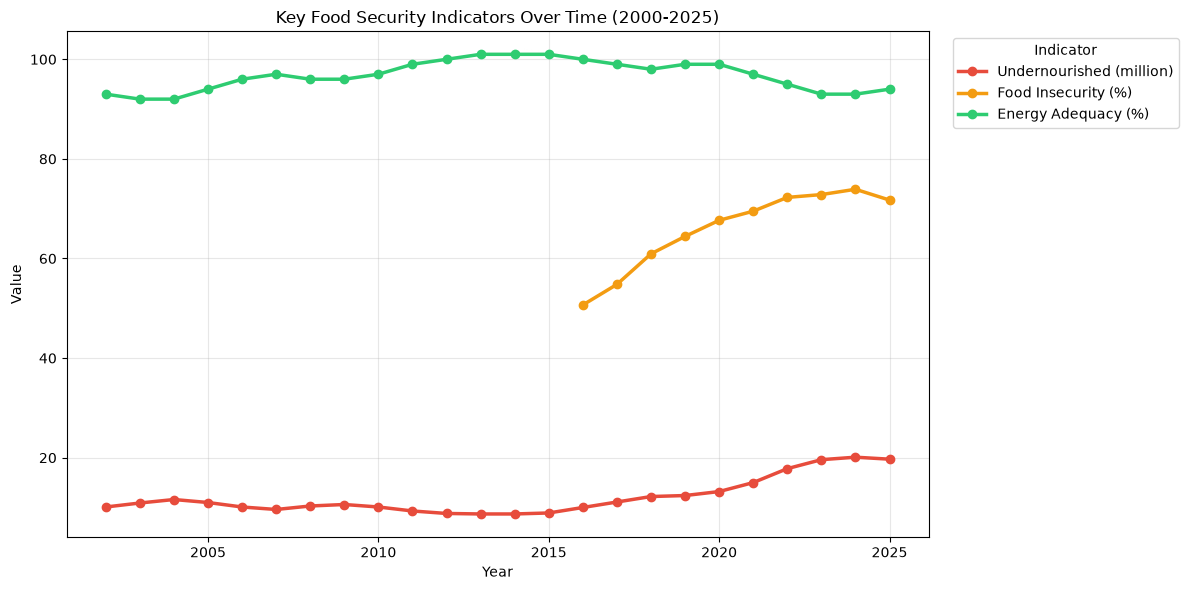

In [10]:
# Tab 1 - The Big Picture (mirrors app: top_indicators_chart)
trend_cols = [
    "undernourished_people_million",
    "moderate_or_severe_food_insecurity_pct",
    "dietary_energy_adequacy_pct",
]
trend_labels = {
    "undernourished_people_million": "Undernourished (million)",
    "moderate_or_severe_food_insecurity_pct": "Food Insecurity (%)",
    "dietary_energy_adequacy_pct": "Energy Adequacy (%)",
}
trend_colors = {
    "Undernourished (million)": "#e74c3c",   # DANGER
    "Food Insecurity (%)": "#f39c12",        # WARNING
    "Energy Adequacy (%)": "#2ecc71",        # SAFE
}

trend_df = analysis_df[["Year"] + trend_cols].melt(
    id_vars="Year",
    var_name="indicator",
    value_name="value",
).dropna()
trend_df["label"] = trend_df["indicator"].map(trend_labels)

plt.figure(figsize=(12, 6))
# draw in app order / colors
for label, color in trend_colors.items():
    sub = trend_df[trend_df["label"] == label]
    plt.plot(sub["Year"], sub["value"], marker="o", linewidth=2.5,
             color=color, label=label)
plt.title("Key Food Security Indicators Over Time (2000-2025)")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend(title="Indicator", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Big picture insight (mirrors the app):** In the latest year, the majority of Kenyans
experience food insecurity while a large share are undernourished - roughly 20 million people.
The number of undernourished Kenyans has roughly doubled since 2002, driven by population
growth outpacing food system improvements. **Economic growth alone has not solved Kenya's food crisis.**

### 5.2 Tab 1 - Correlation: GDP per Capita vs Food Insecurity

Each point is one year. If economic growth helped food security, higher GDP per capita would
be associated with *lower* food insecurity. The app shows this same scatter plot
(no trend line).

In [11]:
# Tab 1 - GDP vs Food Insecurity scatter (mirrors app: correlation_chart)
corr_df = analysis_df[["Year", "gdp_per_capita_ppp", "moderate_or_severe_food_insecurity_pct"]].dropna()

fig_corr = go.Figure()
fig_corr.add_trace(go.Scatter(
    x=corr_df["gdp_per_capita_ppp"],
    y=corr_df["moderate_or_severe_food_insecurity_pct"],
    mode="markers+text",
    marker=dict(
        size=12,
        color=corr_df["Year"],
        colorscale="Viridis",
        showscale=True,
        colorbar=dict(title="Year"),
        line=dict(width=1, color="white"),
    ),
    text=corr_df["Year"],
    textposition="top center",
    textfont=dict(color="white", size=9),
    hovertemplate="<b>Year %{text}</b><br>GDP per capita: $%{x:,.0f}<br>Food Insecurity: %{y:.1f}%<extra></extra>",
))
fig_corr.update_layout(
    title="GDP per Capita vs Food Insecurity Rate",
    xaxis_title="GDP per Capita (PPP, Int$)",
    yaxis_title="Food Insecurity (%)",
    plot_bgcolor="#0e1117", paper_bgcolor="#0e1117",
    font_color="white",
    xaxis=dict(gridcolor="#262730"), yaxis=dict(gridcolor="#262730"),
    height=600,
)
fig_corr.show()

**Correlation insight (mirrors the app):** Despite GDP per capita rising over two
decades, food insecurity did not fall - it *increased*. The correlation is positive, showing
higher GDP is NOT associated with lower food insecurity. Growth benefits have not reached the
poorest Kenyans; income inequality and rising food prices mean **growth alone is insufficient**.

### 5.3 Tab 2 - Availability: Dietary Energy Supply Adequacy

This is the **percentage of the population's daily calorie needs** met by the domestic food
supply. 100% means supply exactly meets demand; below 100% means Kenya relies on imports or aid.
Threshold reference lines (100% target / 95% warning / 90% critical) match the app.

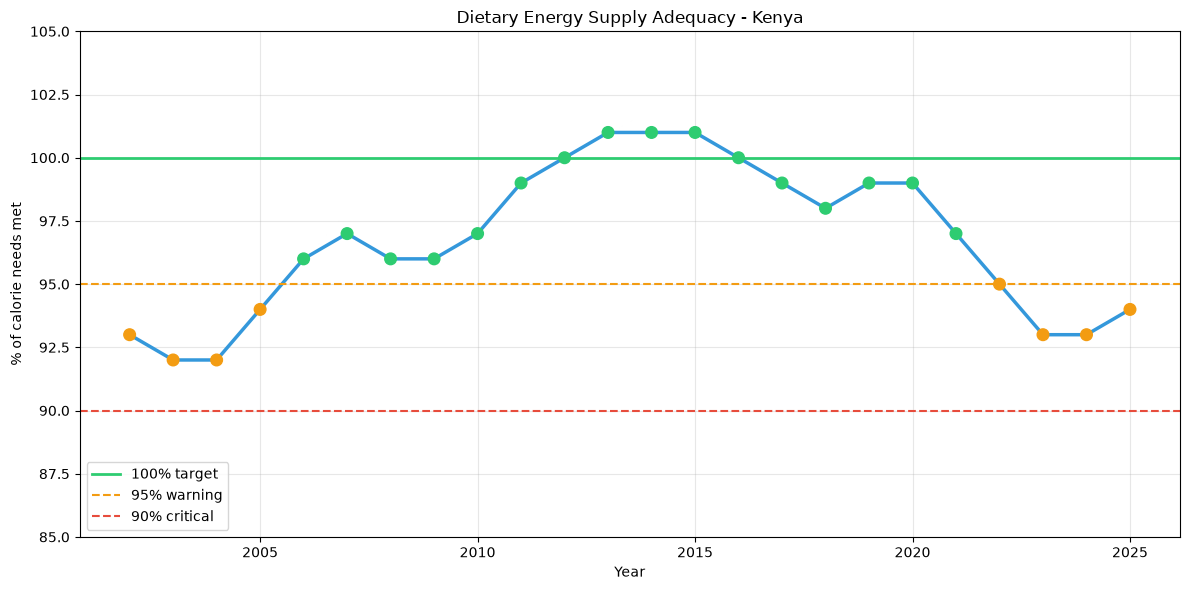

In [12]:
# Tab 2 - Energy adequacy (mirrors app: energy_adequacy_chart)
energy_df = analysis_df[["Year", "dietary_energy_adequacy_pct"]].dropna()

plt.figure(figsize=(12, 6))
plt.plot(energy_df["Year"], energy_df["dietary_energy_adequacy_pct"],
         color="#3498db", linewidth=2.5)
plt.scatter(energy_df["Year"], energy_df["dietary_energy_adequacy_pct"],
            c=energy_df["dietary_energy_adequacy_pct"].apply(
                lambda v: status_color(v, "dietary_energy_adequacy_pct")), s=70, zorder=3)
plt.axhline(100, color="#2ecc71", linestyle="-", linewidth=2, label="100% target")
plt.axhline(95, color="#f39c12", linestyle="--", linewidth=1.5, label="95% warning")
plt.axhline(90, color="#e74c3c", linestyle="--", linewidth=1.5, label="90% critical")
plt.title("Dietary Energy Supply Adequacy - Kenya")
plt.xlabel("Year")
plt.ylabel("% of calorie needs met")
plt.ylim(85, 105)
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Why this matters:** A value below 100% means Kenya cannot produce enough food for its
population and must rely on imports and aid - creating vulnerability to global price shocks.
When global food prices spike (2008, 2022), Kenya experiences immediate food crises.

### 5.4 Tab 2 - Availability: Food Supply Breakdown (per person per day)

Actual nutritional content available per Kenyan per day. Recommended minimums:
**2,100 kcal**, **50 g protein**, **40 g fat**. Dashed lines mark warning / critical thresholds.

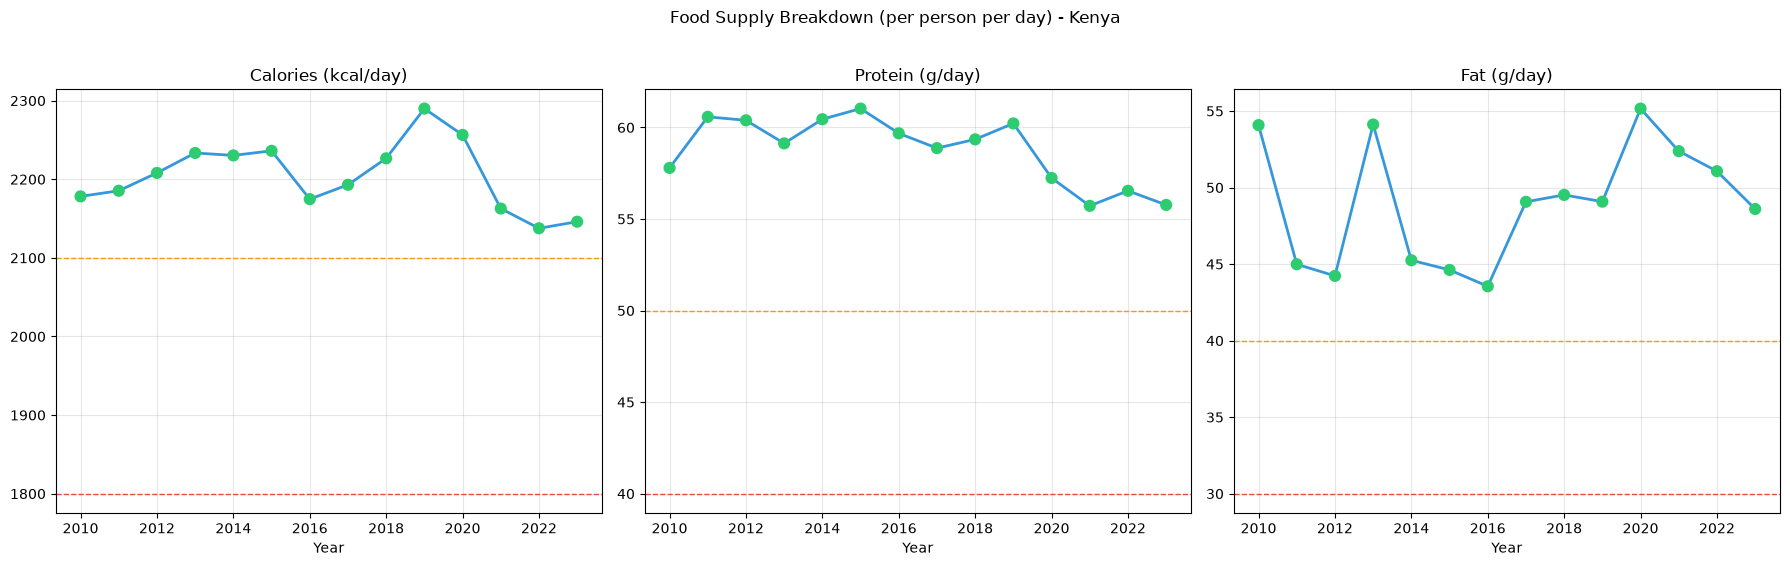

In [13]:
# Tab 2 - Food supply breakdown (mirrors app: supply_breakdown_chart)
supply_specs = [
    ("food_supply_kcal_capita_day", "Calories (kcal/day)", 2100, 1800),
    ("protein_supply_g_capita_day", "Protein (g/day)", 50, 40),
    ("fat_supply_g_capita_day", "Fat (g/day)", 40, 30),
]

fig_sup, axes_sup = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, (ind, title, warn_val, danger_val) in zip(axes_sup, supply_specs):
    d = analysis_df[["Year", ind]].dropna()
    colors = d[ind].apply(lambda v: status_color(v, ind))
    ax.plot(d["Year"], d[ind], color="#3498db", linewidth=2)
    ax.scatter(d["Year"], d[ind], c=colors, s=60, zorder=3)
    ax.axhline(warn_val, color="#f39c12", linestyle="--", linewidth=1)
    ax.axhline(danger_val, color="#e74c3c", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.grid(alpha=0.3)
fig_sup.suptitle("Food Supply Breakdown (per person per day) - Kenya", y=1.02)
plt.tight_layout()
plt.show()

**Supply breakdown insight:** Offering enough calories is necessary but not sufficient -
a diet short on protein and fat leaves people malnourished even when calorie targets are met.
Kenya's supply profile has stayed broadly flat for two decades while the population grew.

### 5.5 Tab 3 - Access & Affordability: Prevalence of Undernourishment

The percentage of Kenya's population that **consistently fails to meet their daily calorie
requirements**. WHO thresholds: <15% acceptable, 15-25% warning, >25% critical.

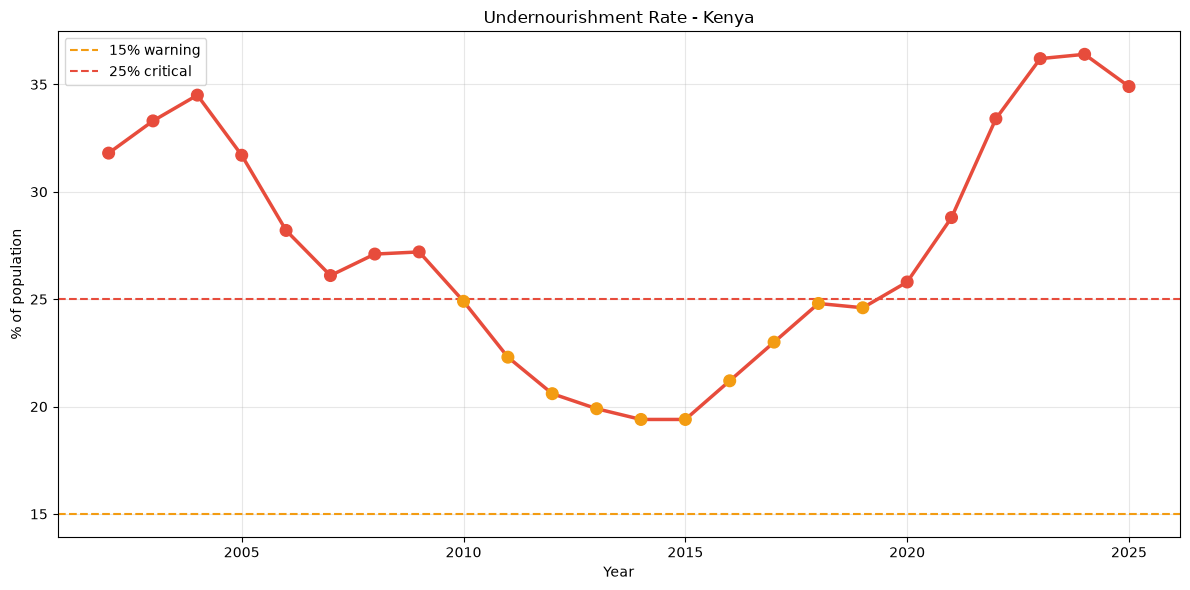

In [14]:
# Tab 3 - Undernourishment (mirrors app: undernourishment_chart)
und_df = analysis_df[["Year", "undernourishment_pct"]].dropna()

plt.figure(figsize=(12, 6))
plt.plot(und_df["Year"], und_df["undernourishment_pct"],
         color="#e74c3c", linewidth=2.5)
plt.scatter(und_df["Year"], und_df["undernourishment_pct"],
            c=und_df["undernourishment_pct"].apply(
                lambda v: status_color(v, "undernourishment_pct")), s=70, zorder=3)
plt.axhline(15, color="#f39c12", linestyle="--", linewidth=1.5, label="15% warning")
plt.axhline(25, color="#e74c3c", linestyle="--", linewidth=1.5, label="25% critical")
plt.title("Undernourishment Rate - Kenya")
plt.xlabel("Year")
plt.ylabel("% of population")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Undernourishment insight:** Roughly 1 in 3 Kenyans consistently fails to meet daily
calorie requirements - a persistent humanitarian crisis needing systemic intervention in food
production, distribution, and affordability.

### 5.6 Tab 3 - Access & Affordability: Food Insecurity Severity

Food insecurity exists on a spectrum:
- **Moderate/Severe**: people who worry about food, are forced to eat less, or skip meals
- **Severe**: people who go entire days without eating

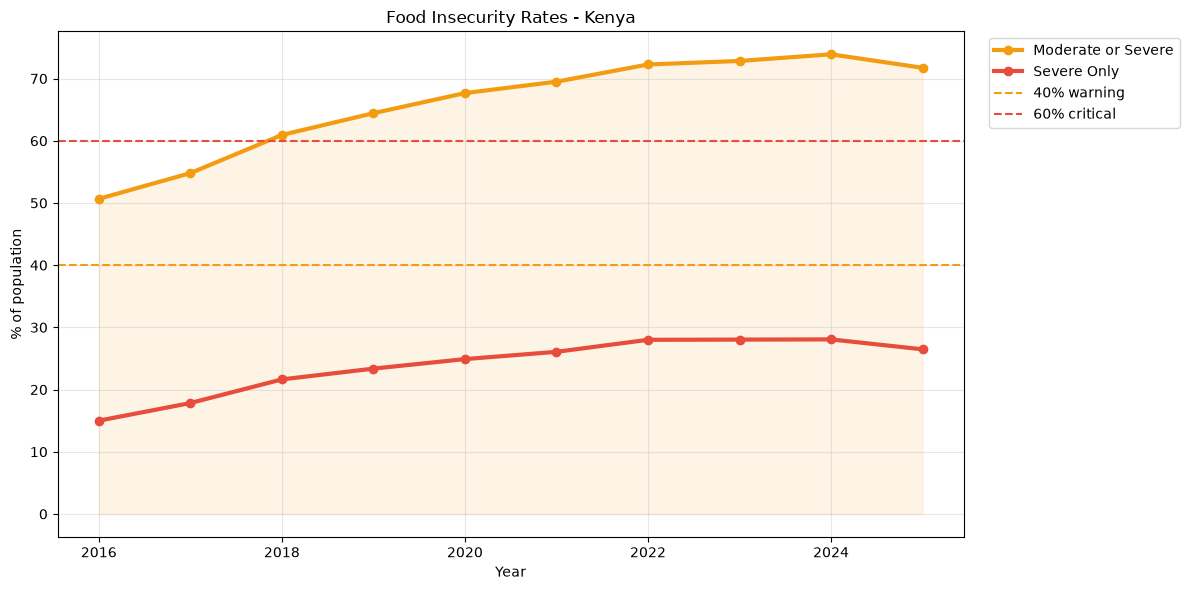

In [15]:
# Tab 3 - Food insecurity severity (mirrors app: food_insecurity_chart)
mod_df = analysis_df[["Year", "moderate_or_severe_food_insecurity_pct"]].dropna()
sev_df = analysis_df[["Year", "severe_food_insecurity_pct"]].dropna()

plt.figure(figsize=(12, 6))
plt.fill_between(mod_df["Year"], mod_df["moderate_or_severe_food_insecurity_pct"],
                 color="#f39c12", alpha=0.1)
plt.plot(mod_df["Year"], mod_df["moderate_or_severe_food_insecurity_pct"],
         color="#f39c12", linewidth=3, marker="o", label="Moderate or Severe")
plt.plot(sev_df["Year"], sev_df["severe_food_insecurity_pct"],
         color="#e74c3c", linewidth=3, marker="o", label="Severe Only")
plt.axhline(40, color="#f39c12", linestyle="--", linewidth=1.5, label="40% warning")
plt.axhline(60, color="#e74c3c", linestyle="--", linewidth=1.5, label="60% critical")
plt.title("Food Insecurity Rates - Kenya")
plt.xlabel("Year")
plt.ylabel("% of population")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Food insecurity insight:** Both measures have worsened significantly since 2016,
reflecting drought, economic shocks, and the COVID-19 pandemic. The narrowing gap means more
people are sliding from moderate into severe food insecurity.

### 5.7 Tab 3 - Access & Affordability: The Affordability Crisis

A **healthy diet** includes fruits, vegetables, protein, and whole grains, not just staple
calories. In Kenya this costs ~$3.20/day (international dollars). These line charts track how
cost and unaffordability have changed over time.

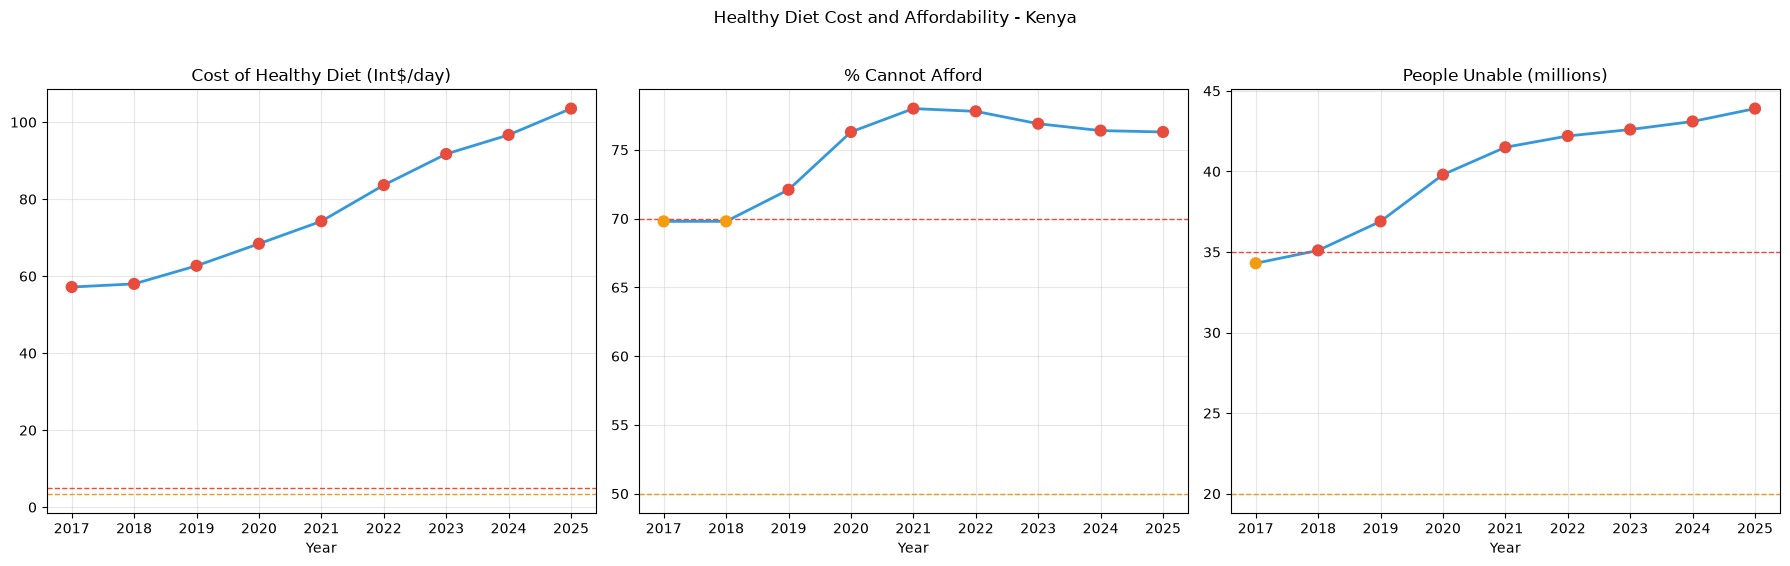

In [16]:
# Tab 3 - Affordability crisis (mirrors app: affordability_chart)
afford_specs = [
    ("healthy_diet_cost_ppp_per_day", "Cost of Healthy Diet (Int$/day)", 3.5, 5.0),
    ("healthy_diet_unaffordable_pct", "% Cannot Afford", 50, 70),
    ("people_unable_afford_healthy_diet_million", "People Unable (millions)", 20, 35),
]

fig_aff, axes_aff = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, (ind, title, warn_val, danger_val) in zip(axes_aff, afford_specs):
    d = analysis_df[["Year", ind]].dropna()
    colors = d[ind].apply(lambda v: status_color(v, ind))
    ax.plot(d["Year"], d[ind], color="#3498db", linewidth=2)
    ax.scatter(d["Year"], d[ind], c=colors, s=60, zorder=3)
    ax.axhline(warn_val, color="#f39c12", linestyle="--", linewidth=1)
    ax.axhline(danger_val, color="#e74c3c", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.grid(alpha=0.3)
fig_aff.suptitle("Healthy Diet Cost and Affordability - Kenya", y=1.02)
plt.tight_layout()
plt.show()

**Affordability insight (the affordability crisis):** Millions of Kenyans cannot afford a
healthy diet. They rely on cheap, nutrient-poor staples - which explains high stunting despite
adequate calorie supply. People get enough calories but not enough nutrients.
**Availability without access is not food security.**

### 5.8 Tab 4 - Child Nutrition: Stunting & Wasting

The impact of food insecurity on children under 5.
- **Stunting** (too short for age) = chronic malnutrition, largely irreversible
- **Wasting** (dangerously thin) = acute malnutrition, potentially reversible

WHO thresholds - Stunting: <20% acceptable, 20-30% warning, >30% critical.
Wasting: <5% acceptable, 5-15% warning, >15% critical.

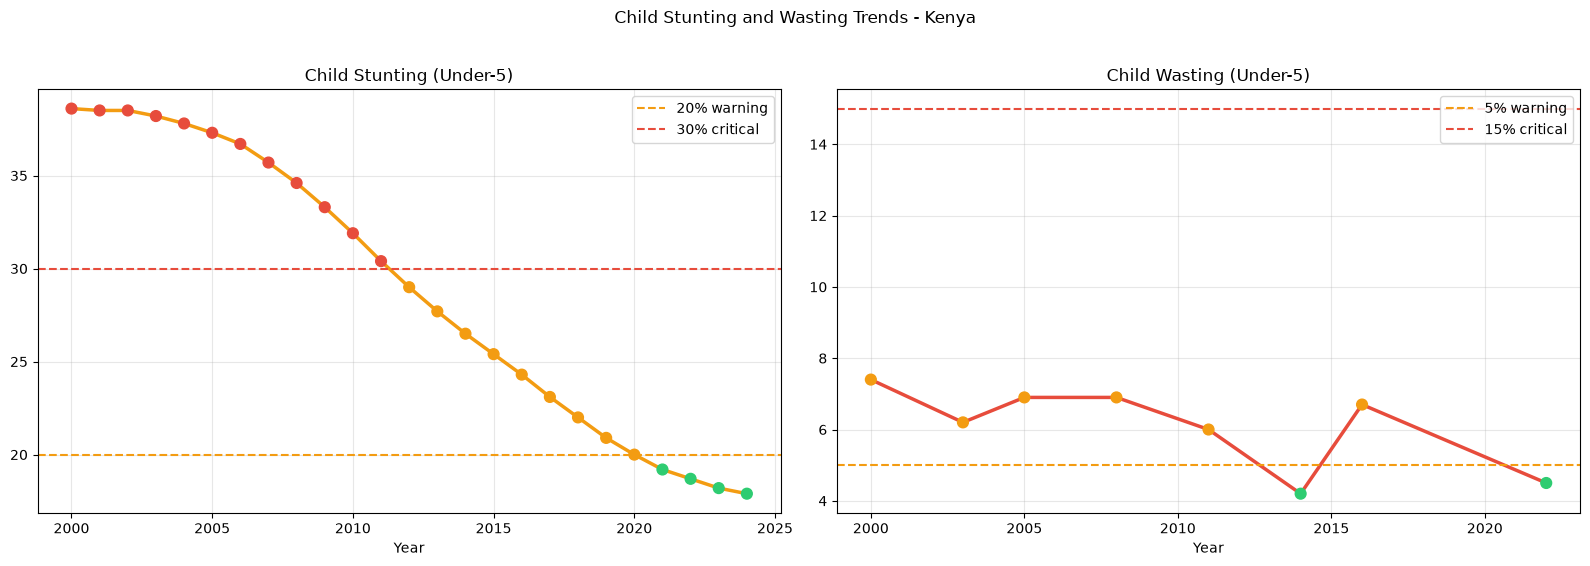

In [17]:
# Tab 4 - Child nutrition (mirrors app: child_nutrition_chart)
st_df = analysis_df[["Year", "under5_stunting_pct"]].dropna()
wa_df = analysis_df[["Year", "under5_wasting_pct"]].dropna()

fig_child, axes_child = plt.subplots(1, 2, figsize=(16, 5.5))

ax = axes_child[0]
ax.plot(st_df["Year"], st_df["under5_stunting_pct"], color="#f39c12", linewidth=2.5)
ax.scatter(st_df["Year"], st_df["under5_stunting_pct"],
           c=st_df["under5_stunting_pct"].apply(lambda v: status_color(v, "under5_stunting_pct")),
           s=60, zorder=3)
ax.axhline(20, color="#f39c12", linestyle="--", linewidth=1.5, label="20% warning")
ax.axhline(30, color="#e74c3c", linestyle="--", linewidth=1.5, label="30% critical")
ax.set_title("Child Stunting (Under-5)")
ax.set_xlabel("Year")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)

ax = axes_child[1]
ax.plot(wa_df["Year"], wa_df["under5_wasting_pct"], color="#e74c3c", linewidth=2.5)
ax.scatter(wa_df["Year"], wa_df["under5_wasting_pct"],
           c=wa_df["under5_wasting_pct"].apply(lambda v: status_color(v, "under5_wasting_pct")),
           s=60, zorder=3)
ax.axhline(5, color="#f39c12", linestyle="--", linewidth=1.5, label="5% warning")
ax.axhline(15, color="#e74c3c", linestyle="--", linewidth=1.5, label="15% critical")
ax.set_title("Child Wasting (Under-5)")
ax.set_xlabel("Year")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)

fig_child.suptitle("Child Stunting and Wasting Trends - Kenya", y=1.02)
plt.tight_layout()
plt.show()

**Progress and challenges:** Stunting has improved dramatically from ~38% (2000) to ~18%,
reflecting decades of nutrition interventions - yet the remaining children still face lifelong
cognitive and physical limits. Wasting fluctuates with drought cycles, so dry seasons can
quickly reverse progress.

### 5.9 Tab 4 - Economic Context: GDP per Capita

Economic growth should theoretically improve food access. GDP per capita (PPP) has grown from
~$3,700 (2000) to ~$5,800 (2024), yet food insecurity has worsened - growth alone does not solve
it without equitable distribution.

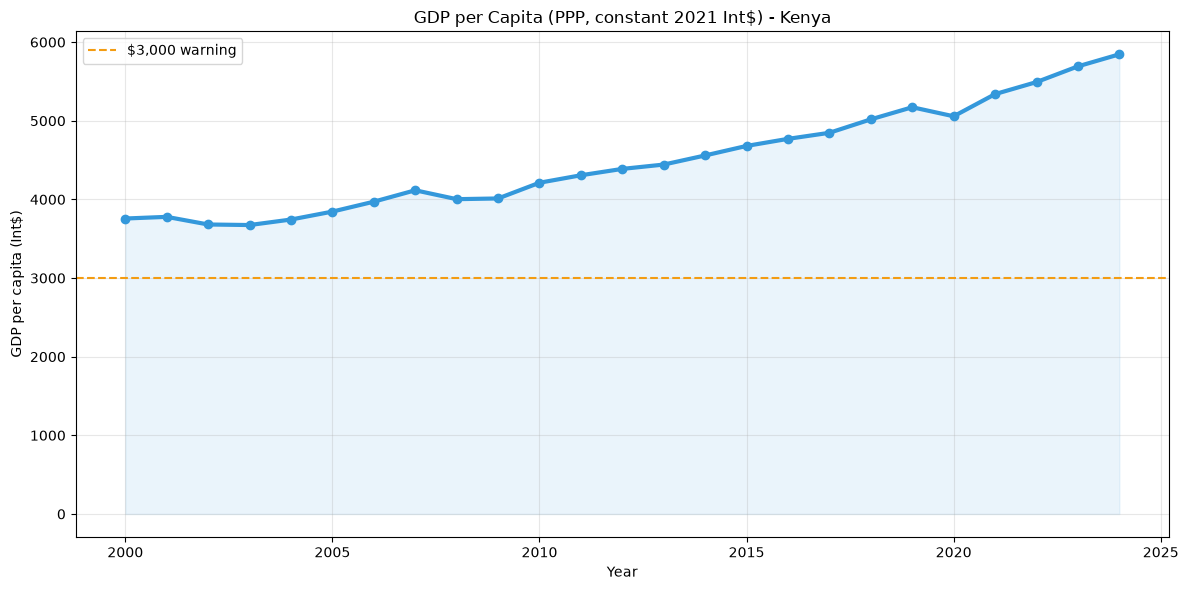

In [18]:
# Tab 4 - GDP per capita (mirrors app: gdp_chart)
gdp_df = analysis_df[["Year", "gdp_per_capita_ppp"]].dropna()

plt.figure(figsize=(12, 6))
plt.fill_between(gdp_df["Year"], gdp_df["gdp_per_capita_ppp"], color="#3498db", alpha=0.1)
plt.plot(gdp_df["Year"], gdp_df["gdp_per_capita_ppp"], color="#3498db", linewidth=3, marker="o")
plt.axhline(3000, color="#f39c12", linestyle="--", linewidth=1.5, label="$3,000 warning")
plt.title("GDP per Capita (PPP, constant 2021 Int$) - Kenya")
plt.xlabel("Year")
plt.ylabel("GDP per capita (Int$)")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**The paradox:** Despite GDP per capita growing over two decades, food insecurity worsened
over the same period. The benefits of growth have not been equitably distributed - income
inequality means the poorest Kenyans have not seen improvements in their ability to afford
nutritious food. Kenya needs **targeted** social protection, agricultural investment, and
nutrition programs.

## 6. Load World Bank JMR County/Sub-County Data

The World Bank Joint Food Security Monitor files are stored as zip files and read directly by Pandas.

Useful files:

- `KEN_JMR_data.zip`: monthly admin-2 food security risk indicators.
- `KEN_JMR_pcodes.zip`: lookup table connecting admin-2 pcodes to counties.
- `kenya_counties.geojson`: Kenya county geometries with admin-1 pcodes.


In [19]:
jmr_data = pd.read_csv(
    JMR_DIR / "KEN_JMR_data.zip",
    parse_dates=["date"],
)

jmr_pcodes = pd.read_csv(JMR_DIR / "KEN_JMR_pcodes.zip")

print("JMR data:", jmr_data.shape)
print("JMR pcodes:", jmr_pcodes.shape)
display(jmr_data.head())
display(jmr_pcodes.head())

JMR data: (1517890, 9)
JMR pcodes: (290, 7)


,iso3,ipc phase cutoff,adm2_pcode,year,month,indicator,grouping,value,date
0,KEN,3,KE001001,2010,1,Target,Original IPC phase,3.0,2010-01-01
1,KEN,3,KE001001,2010,4,Target,Original IPC phase,2.0,2010-04-01
2,KEN,3,KE001001,2010,7,Target,Original IPC phase,2.0,2010-07-01
3,KEN,3,KE001001,2010,10,Target,Original IPC phase,2.0,2010-10-01
4,KEN,3,KE001001,2011,1,Target,Original IPC phase,2.0,2011-01-01


,iso3,adm0_pcode,country,adm1_pcode,adm1_name,adm2_pcode,adm2_name
0,KEN,KEN,Kenya,KE001,Mombasa,KE001001,Changamwe
1,KEN,KEN,Kenya,KE001,Mombasa,KE001002,Jomvu
2,KEN,KEN,Kenya,KE001,Mombasa,KE001003,Kisauni
3,KEN,KEN,Kenya,KE001,Mombasa,KE001004,Nyali
4,KEN,KEN,Kenya,KE001,Mombasa,KE001005,Likoni


In [20]:
print("JMR date range:", jmr_data["date"].min(), "to", jmr_data["date"].max())
print("Admin-2 areas:", jmr_data["adm2_pcode"].nunique())
print("Counties in lookup:", jmr_pcodes["adm1_name"].nunique())

display(
    jmr_data.groupby(["indicator", "grouping"])
    .size()
    .reset_index(name="rows")
    .sort_values(["indicator", "grouping"])
)

JMR date range: 2010-01-01 00:00:00 to 2026-07-01 00:00:00
Admin-2 areas: 290
Counties in lookup: 47


,indicator,grouping,rows
0,Conflict,Alert level,57710
1,Conflict,Indicator value,57710
2,Conflict,Original value,57710
3,Drought - NDVI,Alert level,57710
4,Drought - NDVI,Indicator value,57710
5,Drought - NDVI,Original value,57710
6,Drought - rainfall,Alert level,57710
7,Drought - rainfall,Indicator value,57710
8,Drought - rainfall,Original value,57710
9,Exchange rates,Alert level,57710


## 7. Join JMR Data to County Lookup with `pd.merge`

The main JMR data is keyed by `adm2_pcode`. The lookup table adds county names and county pcodes through `adm1_name` and `adm1_pcode`.


In [21]:
jmr_admin = jmr_data.merge(
    jmr_pcodes[["adm1_pcode", "adm1_name", "adm2_pcode", "adm2_name"]],
    on="adm2_pcode",
    how="left",
)

print(jmr_admin.shape)
print("Rows missing county lookup:", jmr_admin["adm1_name"].isna().sum())
display(jmr_admin.head())

(1517890, 12)
Rows missing county lookup: 0


,iso3,ipc phase cutoff,adm2_pcode,year,month,indicator,grouping,value,date,adm1_pcode,adm1_name,adm2_name
0,KEN,3,KE001001,2010,1,Target,Original IPC phase,3.0,2010-01-01,KE001,Mombasa,Changamwe
1,KEN,3,KE001001,2010,4,Target,Original IPC phase,2.0,2010-04-01,KE001,Mombasa,Changamwe
2,KEN,3,KE001001,2010,7,Target,Original IPC phase,2.0,2010-07-01,KE001,Mombasa,Changamwe
3,KEN,3,KE001001,2010,10,Target,Original IPC phase,2.0,2010-10-01,KE001,Mombasa,Changamwe
4,KEN,3,KE001001,2011,1,Target,Original IPC phase,2.0,2011-01-01,KE001,Mombasa,Changamwe


In [22]:
jmr_admin.dtypes

iso3                           str
ipc phase cutoff             int64
adm2_pcode                     str
year                         int64
month                        int64
indicator                      str
grouping                       str
value                      float64
date                datetime64[us]
adm1_pcode                     str
adm1_name                      str
adm2_name                      str
dtype: object

## 8. Build County-Level JMR Indicators

The World Bank Joint Monitoring Report (JMR) tracks food security risk at the sub-county level.
This data helps identify which counties need the most urgent intervention.

JMR alert levels are numeric:
- `0`: Typical
- `1`: Heightened
- `2`: Critical

The admin-2 records are aggregated to county level by taking the maximum alert level
within each county and date. This highlights whether any sub-county area in a county
reached a heightened or critical risk level.


In [23]:
alert_labels = {0: "Typical", 1: "Heightened", 2: "Critical"}

jmr_alerts = jmr_admin[jmr_admin["grouping"].eq("Alert level")].copy()
jmr_alerts["alert_level"] = jmr_alerts["value"].round().astype("Int64")
jmr_alerts["alert_label"] = jmr_alerts["alert_level"].map(alert_labels)

county_alerts = (
    jmr_alerts
    .groupby(["adm1_pcode", "adm1_name", "date", "indicator"], as_index=False)
    .agg(
        max_alert_level=("alert_level", "max"),
        mean_alert_level=("alert_level", "mean"),
        critical_admin2_count=("alert_level", lambda s: int((s == 2).sum())),
        heightened_admin2_count=("alert_level", lambda s: int((s == 1).sum())),
        admin2_count=("adm2_pcode", "nunique"),
    )
)

latest_alert_date = county_alerts["date"].max()
latest_county_alerts = county_alerts[county_alerts["date"].eq(latest_alert_date)].copy()

print("Latest JMR alert date:", latest_alert_date.date())
display(latest_county_alerts.head())

Latest JMR alert date: 2026-07-01


,adm1_pcode,adm1_name,date,indicator,max_alert_level,mean_alert_level,critical_admin2_count,heightened_admin2_count,admin2_count
1386,KE001,Mombasa,2026-07-01,Conflict,0,0.0,0,0,6
1387,KE001,Mombasa,2026-07-01,Drought - NDVI,0,0.0,0,0,6
1388,KE001,Mombasa,2026-07-01,Drought - rainfall,1,1.0,0,6,6
1389,KE001,Mombasa,2026-07-01,Exchange rates,0,0.0,0,0,6
1390,KE001,Mombasa,2026-07-01,Food prices,0,0.0,0,0,6


In [24]:
county_risk_summary = (
    latest_county_alerts
    .groupby(["adm1_pcode", "adm1_name"], as_index=False)
    .agg(
        overall_max_alert=("max_alert_level", "max"),
        total_critical_admin2_flags=("critical_admin2_count", "sum"),
        total_heightened_admin2_flags=("heightened_admin2_count", "sum"),
        indicators_at_critical=("max_alert_level", lambda s: int((s == 2).sum())),
        indicators_at_heightened=("max_alert_level", lambda s: int((s == 1).sum())),
        indicators_available=("indicator", "nunique"),
    )
)
county_risk_summary["overall_alert_label"] = county_risk_summary["overall_max_alert"].map(alert_labels)
county_risk_summary = county_risk_summary.sort_values(
    ["overall_max_alert", "total_critical_admin2_flags", "total_heightened_admin2_flags"],
    ascending=False,
)

display(county_risk_summary.head(15))

,adm1_pcode,adm1_name,overall_max_alert,total_critical_admin2_flags,total_heightened_admin2_flags,indicators_at_critical,indicators_at_heightened,indicators_available,overall_alert_label
7,KE008,Wajir,2,6,0,1,0,7,Critical
1,KE002,Kwale,2,4,5,1,2,7,Critical
8,KE009,Mandera,2,4,3,2,0,7,Critical
6,KE007,Garissa,2,4,0,2,0,7,Critical
2,KE003,Kilifi,2,2,6,1,1,7,Critical
9,KE010,Marsabit,2,2,2,1,0,7,Critical
13,KE014,Embu,2,2,2,1,0,7,Critical
4,KE005,Lamu,2,2,1,1,1,7,Critical
12,KE013,Tharaka-Nithi,2,2,1,1,0,7,Critical
0,KE001,Mombasa,2,1,7,1,1,7,Critical


In [25]:
county_indicator_matrix = latest_county_alerts.pivot_table(
    index=["adm1_pcode", "adm1_name"],
    columns="indicator",
    values="max_alert_level",
    aggfunc="max",
).reset_index()
county_indicator_matrix.columns.name = None

display(county_indicator_matrix.head())

,adm1_pcode,adm1_name,Conflict,Drought - NDVI,Drought - rainfall,Exchange rates,Food prices,Volatility - Exchange rate,Volatility - Food prices
0,KE001,Mombasa,0,0,1,0,0,0,2
1,KE002,Kwale,0,0,1,0,1,0,2
2,KE003,Kilifi,0,0,2,0,0,0,1
3,KE004,Tana River,0,0,0,0,0,0,1
4,KE005,Lamu,0,0,2,0,0,0,1


## 9. Join County Risk Data to GeoDataFrame

The county boundary GeoJSON has `ADM1_PCODE`; the JMR county table has `adm1_pcode`.
This gives us a clean join key for true county choropleth maps.

These choropleth maps show:
- **Overall Alert Level**: Maximum alert level across all indicators per county
- **Critical Alert Count**: Number of sub-counties with critical flags

Darkest red indicates the highest risk counties requiring immediate intervention.


In [26]:
kenya_counties = gpd.read_file(SHAPEFILE_DIR / "kenya_counties.geojson").to_crs("EPSG:4326")
kenya_counties = kenya_counties.rename(columns={"ADM1_PCODE": "adm1_pcode", "ADM1_EN": "county_name"})

county_geo_df = kenya_counties.merge(county_risk_summary, on="adm1_pcode", how="left")
county_geo_df = gpd.GeoDataFrame(county_geo_df, geometry="geometry", crs=kenya_counties.crs)

print(county_geo_df.shape)
print("Counties without JMR data:", county_geo_df["overall_max_alert"].isna().sum())
display(county_geo_df[["county_name", "adm1_pcode", "overall_max_alert", "overall_alert_label"]].head())

(47, 84)
Counties without JMR data: 0


,county_name,adm1_pcode,overall_max_alert,overall_alert_label
0,Baringo,KE030,0,Typical
1,Bomet,KE036,0,Typical
2,Bungoma,KE039,0,Typical
3,Busia,KE040,0,Typical
4,Elgeyo-Marakwet,KE028,0,Typical


## 10. County Risk Charts (Closing the Streamlit App - Tab 5)

These visualizations mirror the **County Risk Map** tab of the Streamlit app, in the same order:

1. **Choropleth maps** - overall alert level and critical alert count by county
2. **County Risk Ranking** - top 15 highest-risk counties (stacked bars)
3. **Top 10 Counties** - critical vs heightened alerts (grouped bars)
4. **County x Indicator heatmap** - alert level per indicator per county

Alert levels: **Typical** (0) | **Heightened** (1) | **Critical** (2).

### 9.1 Tab 5 - County Risk Choropleth Maps

These maps show the food security risk level for each of Kenya's 47 counties using the JMR
maximum alert level (left) and the number of critical admin-2 indicator flags (right).
The app shows the same two maps, switchable via a dropdown.

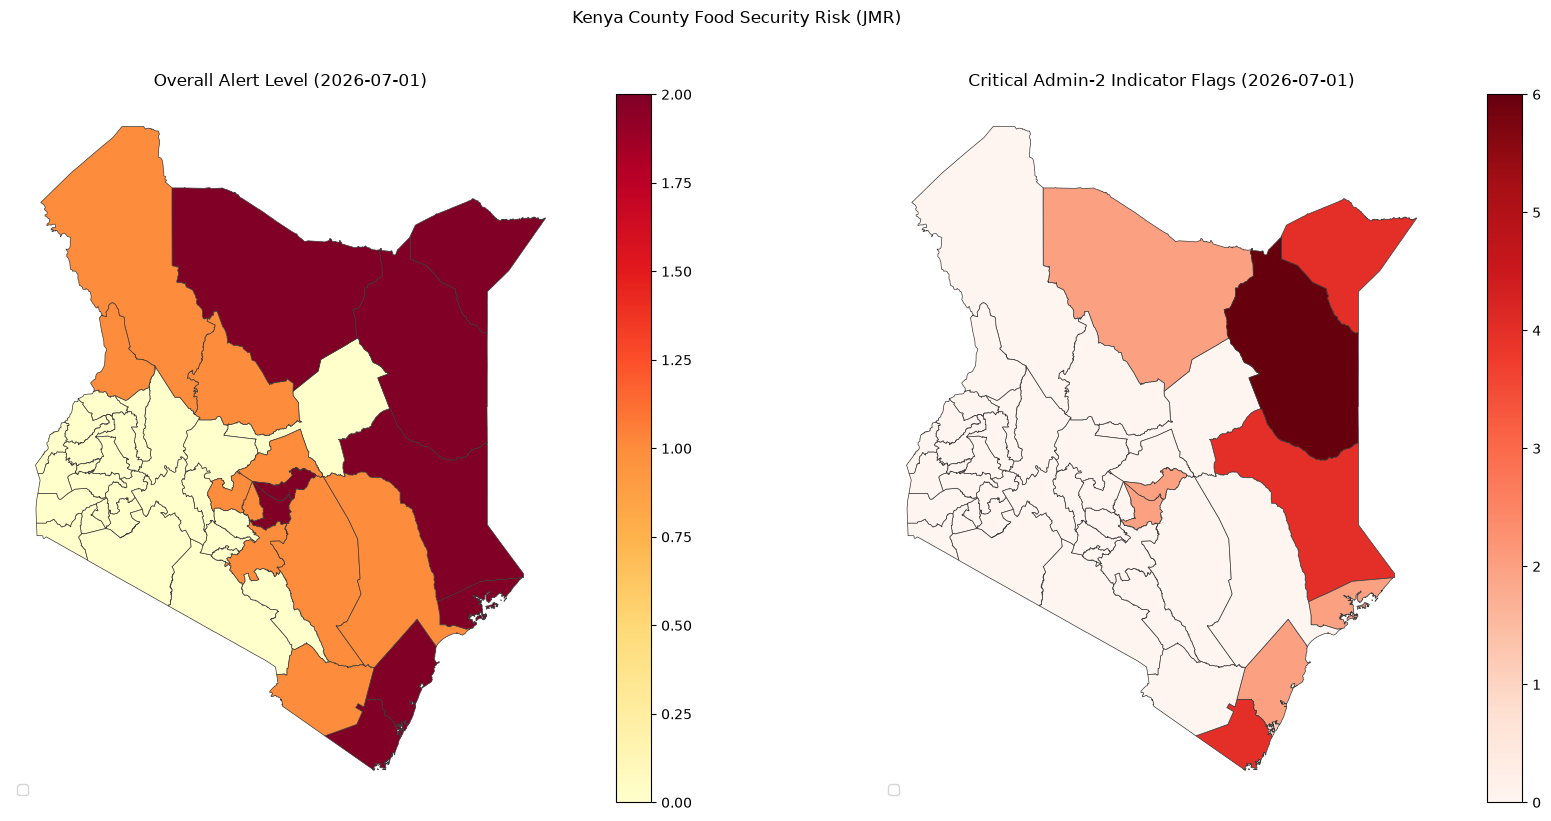

In [27]:
# Tab 5 - Choropleth maps (mirrors app: choropleth_chart)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

county_geo_df.plot(
    column="overall_max_alert",
    cmap="YlOrRd",
    vmin=0, vmax=2,
    legend=True,
    edgecolor="#3a3a3a", linewidth=0.5,
    ax=axes[0],
    missing_kwds={"color": "#f0f0f0", "label": "No data"},
)
axes[0].set_title(f"Overall Alert Level ({latest_alert_date.date()})")
axes[0].set_axis_off()
axes[0].legend(loc="lower left")

county_geo_df.plot(
    column="total_critical_admin2_flags",
    cmap="Reds",
    legend=True,
    edgecolor="#3a3a3a", linewidth=0.5,
    ax=axes[1],
    missing_kwds={"color": "#f0f0f0", "label": "No data"},
)
axes[1].set_title(f"Critical Admin-2 Indicator Flags ({latest_alert_date.date()})")
axes[1].set_axis_off()
axes[1].legend(loc="lower left")

fig.suptitle("Kenya County Food Security Risk (JMR)", y=1.02)
plt.tight_layout()
plt.show()

**County risk insight:** Some counties are at **critical** overall risk and several more at
**heightened** risk across the alert indicators. These are the areas where climate shocks,
conflict, food-price spikes, and exchange-rate volatility are combining to push sub-counties
past critical thresholds - priority assistance and early-warning response should target them first.

### 9.2 Tab 5 - County Risk Ranking: Top 15 Highest-Risk Counties

Stacked bar chart (critical + heightened flags) for the 15 most affected counties - the same
chart shown in the app's ranking panel.

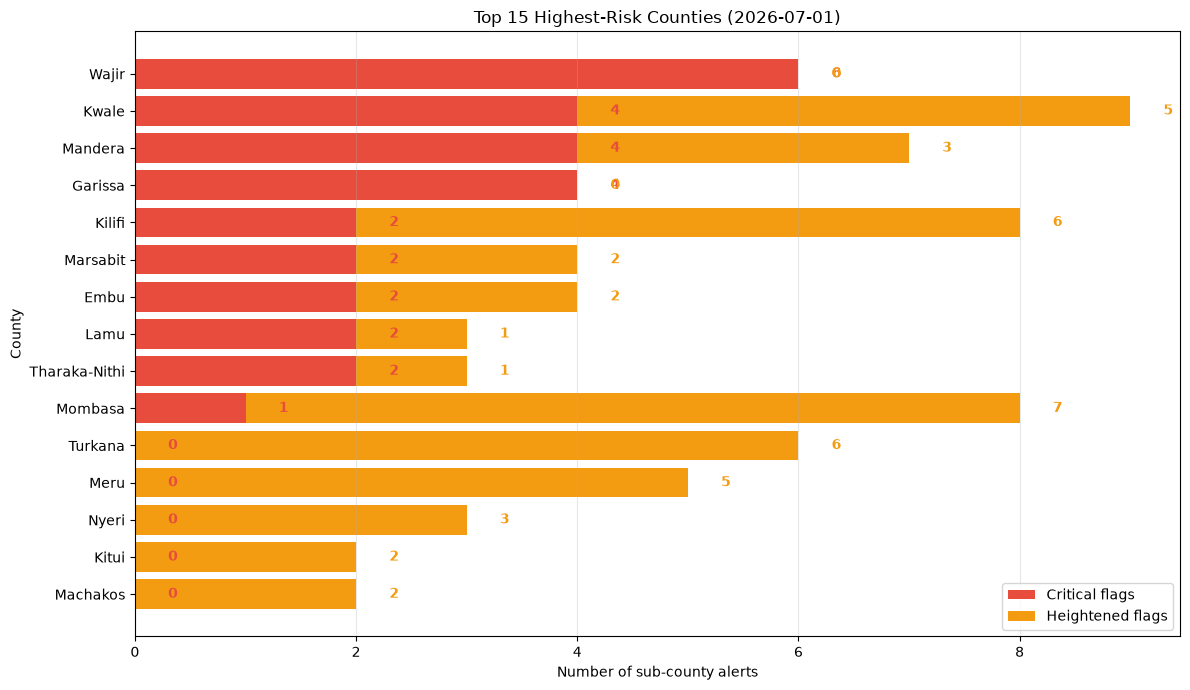

In [28]:
# Tab 5 - County risk ranking (mirrors app: county_ranking_chart)
top_counties = county_risk_summary.head(15).copy()
top_counties_rev = top_counties.iloc[::-1]

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(top_counties_rev["adm1_name"], top_counties_rev["total_critical_admin2_flags"],
        color="#e74c3c", label="Critical flags")
ax.barh(top_counties_rev["adm1_name"], top_counties_rev["total_heightened_admin2_flags"],
        color="#f39c12", label="Heightened flags", left=top_counties_rev["total_critical_admin2_flags"])
for i, (__, row) in enumerate(top_counties_rev.iterrows()):
    ax.text(row["total_critical_admin2_flags"] + 0.3, i, str(row["total_critical_admin2_flags"]),
            va="center", color="#e74c3c", fontweight="bold")
    ax.text(row["total_critical_admin2_flags"] + row["total_heightened_admin2_flags"] + 0.3, i,
            str(row["total_heightened_admin2_flags"]), va="center", color="#f39c12", fontweight="bold")
ax.set_title(f"Top 15 Highest-Risk Counties ({latest_alert_date.date()})")
ax.set_xlabel("Number of sub-county alerts")
ax.set_ylabel("County")
ax.legend(loc="lower right")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

### 9.3 Tab 5 - Top 10 Counties: Critical vs Heightened Alerts

Grouped bar chart comparing critical and heightened alert counts for the 10 most affected
counties. This is a snapshot comparison, not a time series - matching the app's chart.

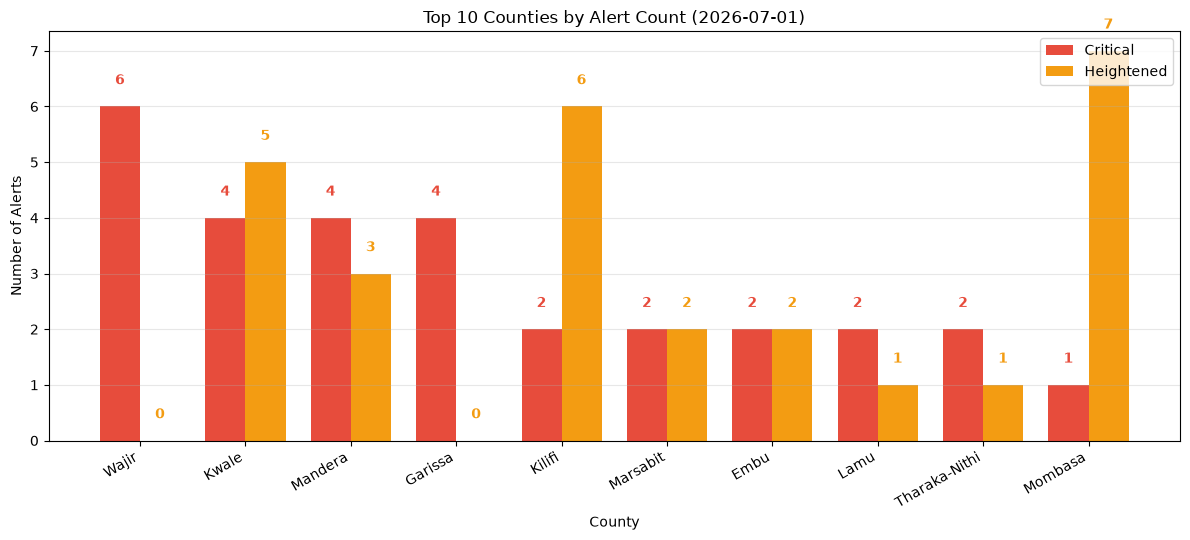

In [29]:
# Tab 5 - Top 10 counties grouped bars (mirrors app: top10_chart)
top10 = county_risk_summary.head(10).copy()
x = np.arange(len(top10))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 5.5))
b1 = ax.bar(x - width / 2, top10["total_critical_admin2_flags"], width,
            color="#e74c3c", label="Critical")
b2 = ax.bar(x + width / 2, top10["total_heightened_admin2_flags"], width,
            color="#f39c12", label="Heightened")
for b in b1:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.4,
            int(b.get_height()), ha="center", color="#e74c3c", fontweight="bold")
for b in b2:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.4,
            int(b.get_height()), ha="center", color="#f39c12", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(top10["adm1_name"], rotation=30, ha="right")
ax.set_title(f"Top 10 Counties by Alert Count ({latest_alert_date.date()})")
ax.set_xlabel("County")
ax.set_ylabel("Number of Alerts")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

### 9.4 Tab 5 - County x Indicator Heatmap

The **maximum alert level** for each county across all JMR indicators.
Red = at least one sub-county in that county reached critical level for that indicator.
This mirrors the app's heatmap exactly (same pivot and ordering).

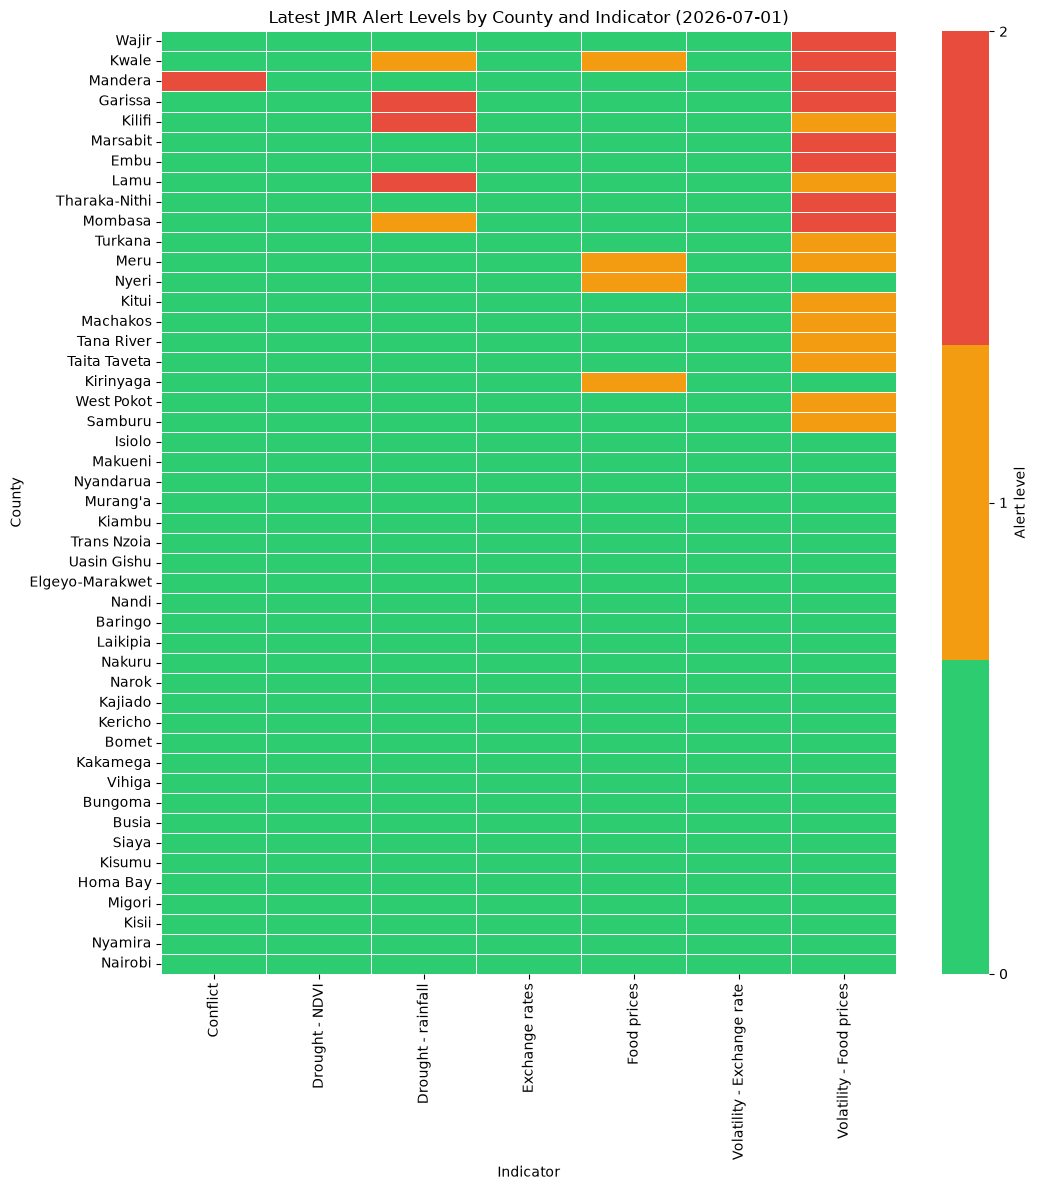

In [30]:
# Tab 5 - County x Indicator heatmap (mirrors app: heatmap_chart)
heatmap_data = county_indicator_matrix.set_index("adm1_name").drop(columns="adm1_pcode")
heatmap_data = heatmap_data.loc[county_risk_summary["adm1_name"]]
heatmap_data = heatmap_data.astype(float)

plt.figure(figsize=(11, 12))
sns.heatmap(
    heatmap_data,
    cmap=sns.color_palette(["#2ecc71", "#f39c12", "#e74c3c"], as_cmap=True),
    vmin=0, vmax=2,
    linewidths=0.4, linecolor="white",
    cbar_kws={"ticks": [0, 1, 2], "label": "Alert level"},
)
plt.title(f"Latest JMR Alert Levels by County and Indicator ({latest_alert_date.date()})")
plt.xlabel("Indicator")
plt.ylabel("County")
plt.tight_layout()
plt.show()

**Reading the heatmap:** Each cell shows the maximum alert level (Typical 0 / Heightened 1 /
Critical 2) reached by any sub-county for a given indicator. **Red** cells mean that indicator
already triggered a critical alert somewhere in that county - warranting immediate action.
Indicators covering food prices, exchange rates, drought (NDVI and rainfall), and conflict move
independently, so a county can be critical on one indicator while typical on another.